# When does DoRA help?

**A controlled confirmatory study of adapter geometry, parameter budgets, and few-shot domain adaptation**  
Vladislav Lapin · MIPT FPMI / AI360 · AIRI Summer School 2026

## Technical summary

- Mixed-shift DoRA−LoRA is **+1.06 pp** in the MLP (`n=20`) and **+0.92 pp** in the CNN (`n=10`).
- The sign replicates across two backbones and all four target-data budgets, but Holm-corrected individual tests are not uniformly decisive.
- Magnitude-only wins the pure-contrast control; parameter-matched LoRA ties DoRA on MLP rotation.
- Trained synthetic DoRA usually realizes its capacity advantage, but convergence falls to 88% under the strongest magnitude shift.

The contribution is a conditional result with uncertainty, not a claim that DoRA always beats LoRA.


## Protocol and evidence boundary

Pilot seeds select learning rates and MLP rank allocations using target validation only. Confirmatory seeds are disjoint, and target test is evaluated after every configuration is frozen. The real-data benchmark uses `sklearn Digits`; it is not an LLM reproduction. The exact protocol is saved in `docs/EXTENSION_PROTOCOL.md`.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image

ROOT = Path.cwd()
extension_audit = json.loads((ROOT / "results" / "extension_validation.json").read_text())
robustness_audit = json.loads((ROOT / "results" / "robustness_validation.json").read_text())
assert extension_audit["status"] == "ready_to_share" and not extension_audit["issues"]
assert robustness_audit["status"] == "ready_to_share" and not robustness_audit["issues"]
{"confirmatory": extension_audit, "robustness": robustness_audit}

{'confirmatory': {'status': 'ready_to_share', 'issues': [], 'confirmatory_rows': 660, 'architectures': ['cnn', 'mlp'], 'scenarios': ['contrast', 'mixed', 'rotation'], 'generated_files': ['results/extension_accuracy_summary.csv', 'results/extension_paired_comparisons.csv', 'docs/EXTENSION_VALIDATION.md']}, 'robustness': {'status': 'ready_to_share', 'issues': [], 'data_sweep_rows': 400, 'synthetic_optimization_rows': 150, 'inference_unit_for_synthetic': 'problem_seed'}}

## Validation-selected configurations

In [2]:
mlp_selected = pd.read_csv(ROOT / "results" / "confirmatory_mlp" / "selected_configs.csv", dtype={"allocation": str})
cnn_selected = pd.read_csv(ROOT / "results" / "confirmatory_cnn" / "selected_configs.csv", dtype={"allocation": str})

selected = pd.concat([mlp_selected, cnn_selected], ignore_index=True)
selected[[
    "architecture", "scenario", "method_id", "allocation", "learning_rate",
    "trainable_parameters", "validation_accuracy_mean"
]].sort_values(["architecture", "scenario", "method_id"]).round(4)

,architecture,scenario,method_id,allocation,learning_rate,trainable_parameters,validation_accuracy_mean
24,cnn,contrast,dora,4-4-4-4,0.0300,1990,0.9606
25,cnn,contrast,frozen,0-0-0-0,0.0000,0,0.2639
26,cnn,contrast,full,0-0-0-0,0.0003,13706,0.9711
27,cnn,contrast,lora,4-4-4-4,0.0300,1868,0.9594
28,cnn,contrast,lora_plus,4-4-4-4,0.0003,1868,0.9622
29,cnn,contrast,magnitude,0-0-0-0,0.0300,122,0.9806
30,cnn,mixed,dora,4-4-4-4,0.0100,1990,0.8311
31,cnn,mixed,frozen,0-0-0-0,0.0000,0,0.6028
32,cnn,mixed,full,0-0-0-0,0.0010,13706,0.8267
33,cnn,mixed,lora,4-4-4-4,0.0100,1868,0.8239


## Confirmatory result: the mixed effect repeats across backbones

Intervals below are paired within architecture and seed. Similar point estimates in the MLP and CNN are stronger evidence than one favorable mean, while the intervals and adjusted p-values prevent overclaiming.


In [3]:
comparisons = pd.read_csv(ROOT / "results" / "extension_paired_comparisons.csv")
comparisons.query("comparison == 'dora_vs_lora'")[[
    "architecture", "scenario", "mean_delta_pp", "ci95_low_pp", "ci95_high_pp",
    "paired_effect_dz", "paired_t_p", "paired_t_p_holm", "wins", "ties", "losses", "n_pairs"
]].round(4)

,architecture,scenario,mean_delta_pp,ci95_low_pp,ci95_high_pp,paired_effect_dz,paired_t_p,paired_t_p_holm,wins,ties,losses,n_pairs
0,mlp,contrast,-0.1944,-0.5374,0.1485,-0.2654,0.2499,0.7728,7,4,9,20
4,cnn,contrast,-0.3056,-1.1138,0.5027,-0.2704,0.4146,0.9018,3,1,6,10
6,mlp,rotation,0.4167,-0.2872,1.1206,0.2770,0.2305,0.7728,10,3,7,20
10,cnn,rotation,0.3611,-0.3827,1.1049,0.3473,0.3006,0.9018,6,0,4,10
12,mlp,mixed,1.0556,-0.0664,2.1775,0.4403,0.0637,0.3822,15,0,5,20
16,cnn,mixed,0.9167,0.0998,1.7336,0.8027,0.0318,0.1590,8,0,2,10


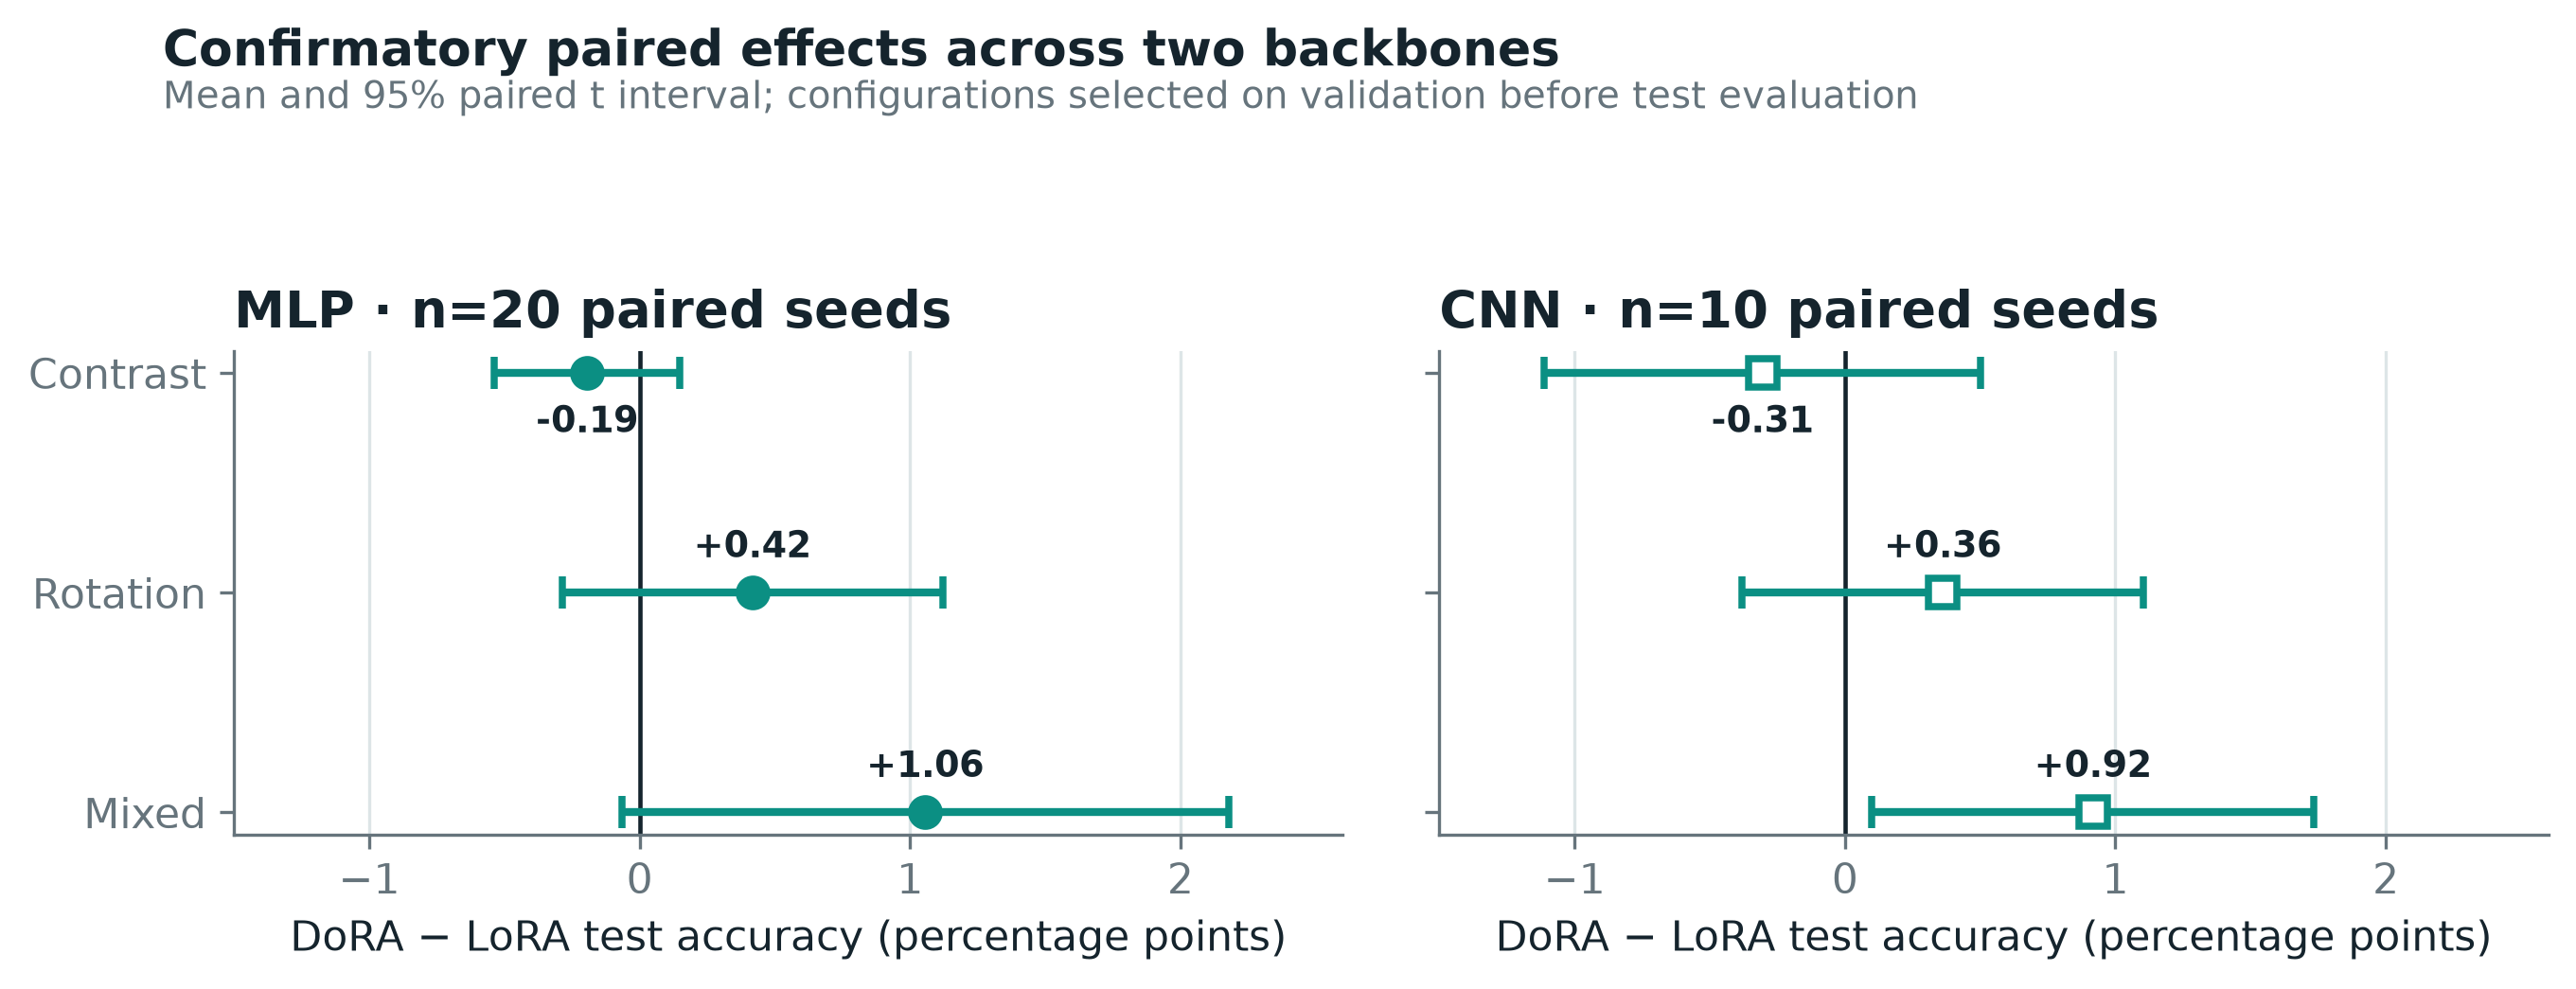

In [4]:
Image(filename=ROOT / "figures" / "extension" / "confirmatory_dora_minus_lora.png", width=950, embed=True)

## Stronger and nearly parameter-matched baselines

In [5]:
mixed_primary = comparisons.query(
    "architecture == 'mlp' and scenario == 'mixed' and numerator == 'dora'"
)[[
    "comparator", "mean_delta_pp", "ci95_low_pp", "ci95_high_pp", "paired_effect_dz",
    "paired_t_p_holm", "wilcoxon_p_holm", "wins", "ties", "losses"
]]
mixed_primary.round(4)

,comparator,mean_delta_pp,ci95_low_pp,ci95_high_pp,paired_effect_dz,paired_t_p_holm,wilcoxon_p_holm,wins,ties,losses
12,lora,1.0556,-0.0664,2.1775,0.4403,0.3822,0.4024,15,0,5
13,lora_plus,1.4306,0.4538,2.4073,0.6854,0.0509,0.1000,14,1,5
14,lora_matched,0.5278,-0.2911,1.3466,0.3016,0.7728,0.7348,11,1,8


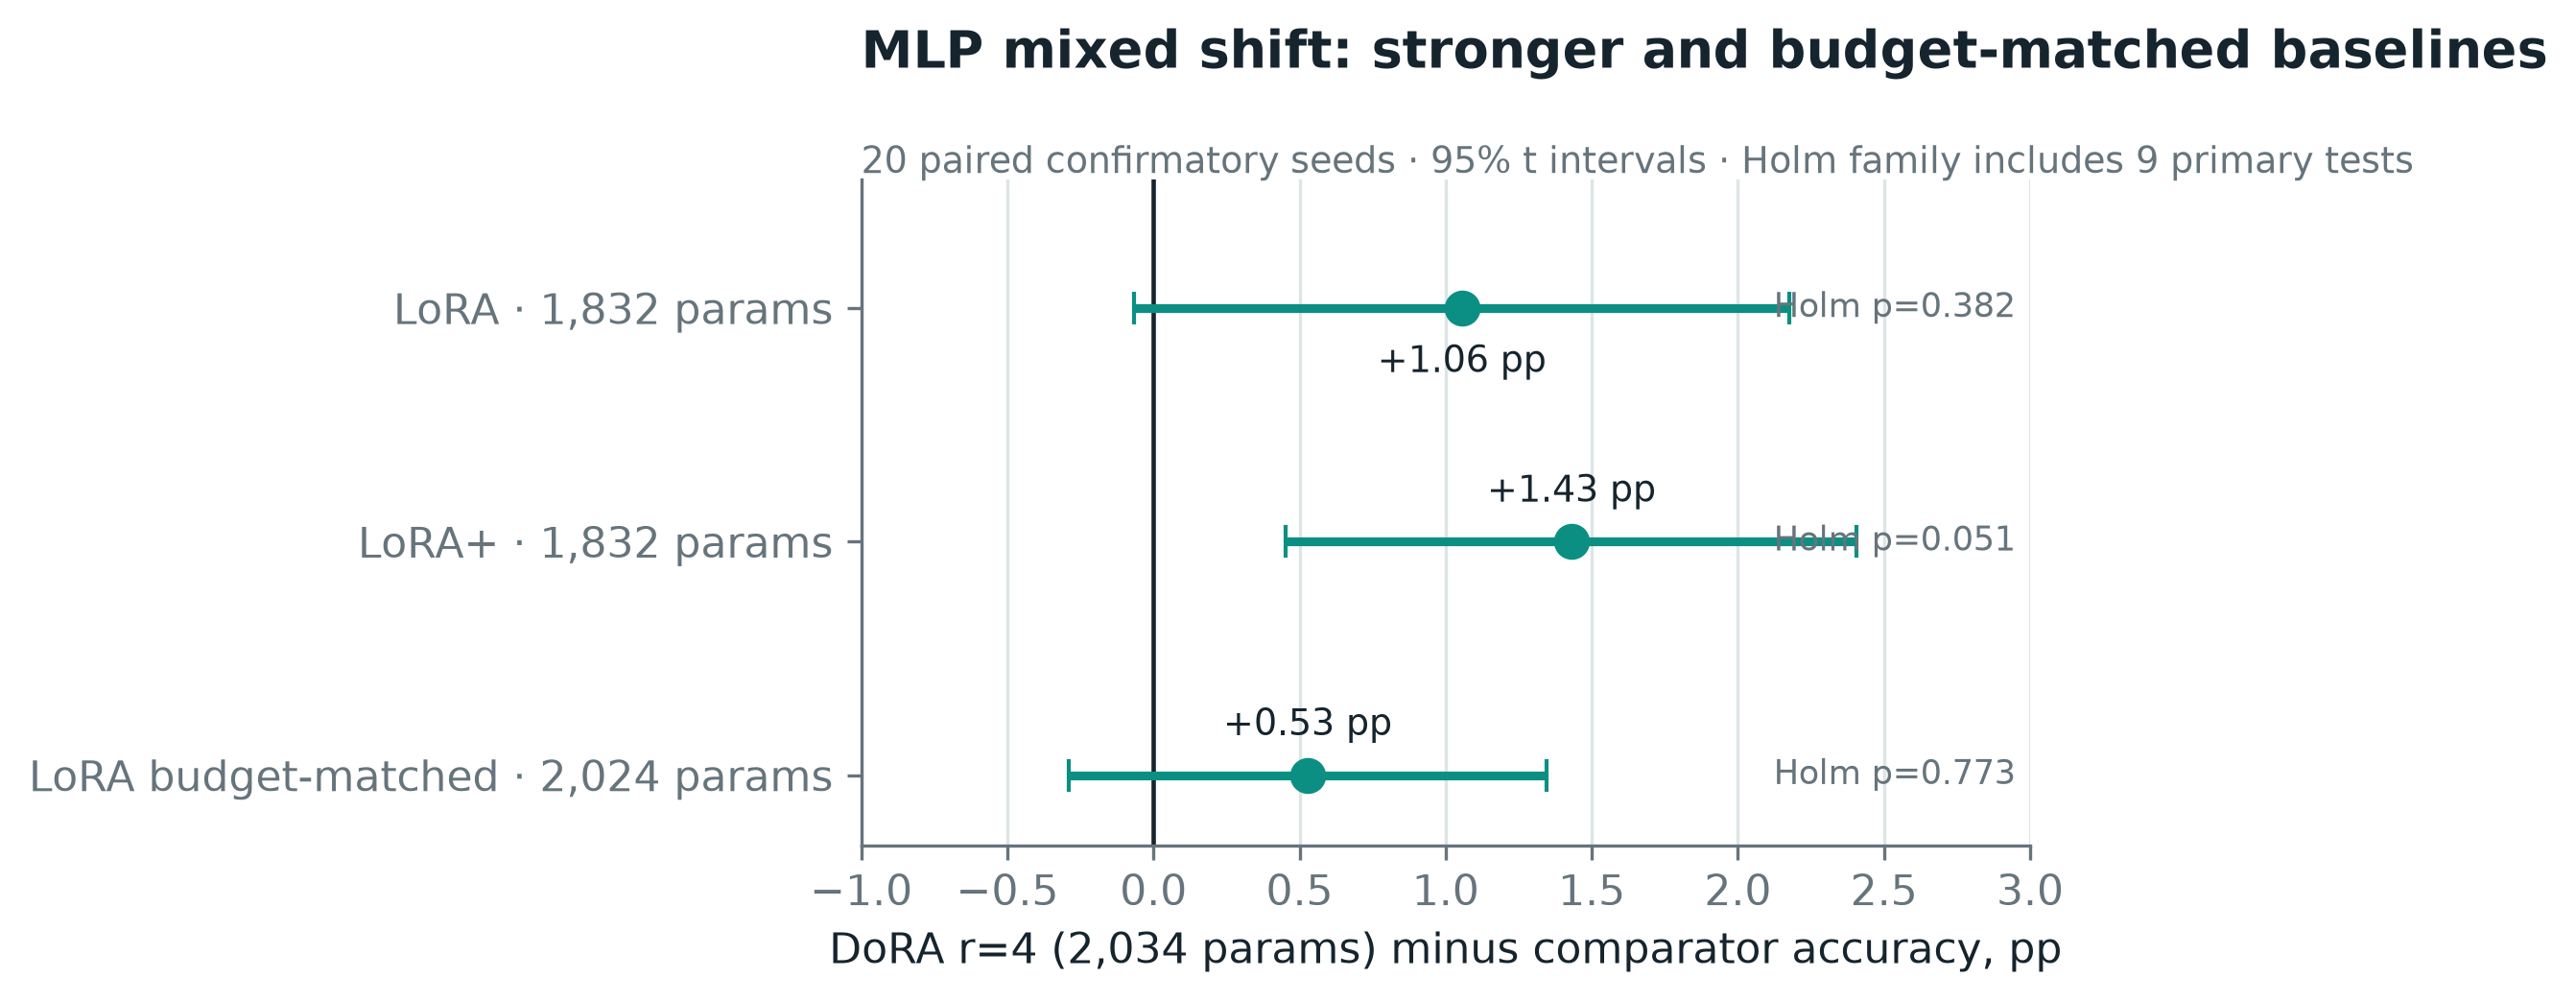

In [6]:
Image(filename=ROOT / "figures" / "extension" / "mixed_strong_baselines.png", width=850, embed=True)

## Target-data sweep

The 50/100/200/400-example subsets are class-balanced and nested. A retained sample keeps the same corruption realization, and every method reuses the mixed-shift configuration selected before this sweep.


In [7]:
data_accuracy = pd.read_csv(ROOT / "results" / "data_sweep_mlp" / "data_sweep_accuracy_ci.csv")
data_delta = pd.read_csv(ROOT / "results" / "data_sweep_mlp" / "data_sweep_paired_comparisons.csv")
data_accuracy[data_accuracy["method_id"].isin(["dora", "lora", "lora_plus"])][[
    "adaptation_examples", "method", "accuracy_mean_pct", "accuracy_ci95_low_pct", "accuracy_ci95_high_pct"
]].round(2)

,adaptation_examples,method,accuracy_mean_pct,accuracy_ci95_low_pct,accuracy_ci95_high_pct
0,50,DoRA,61.47,60.51,62.44
2,50,LoRA,61.01,60.14,61.89
4,50,LoRA+,59.01,58.14,59.89
5,100,DoRA,65.82,64.57,67.07
7,100,LoRA,65.29,64.42,66.16
9,100,LoRA+,62.99,61.86,64.12
10,200,DoRA,70.65,69.46,71.85
12,200,LoRA,69.74,68.61,70.86
14,200,LoRA+,68.90,67.94,69.87
15,400,DoRA,74.86,73.85,75.87


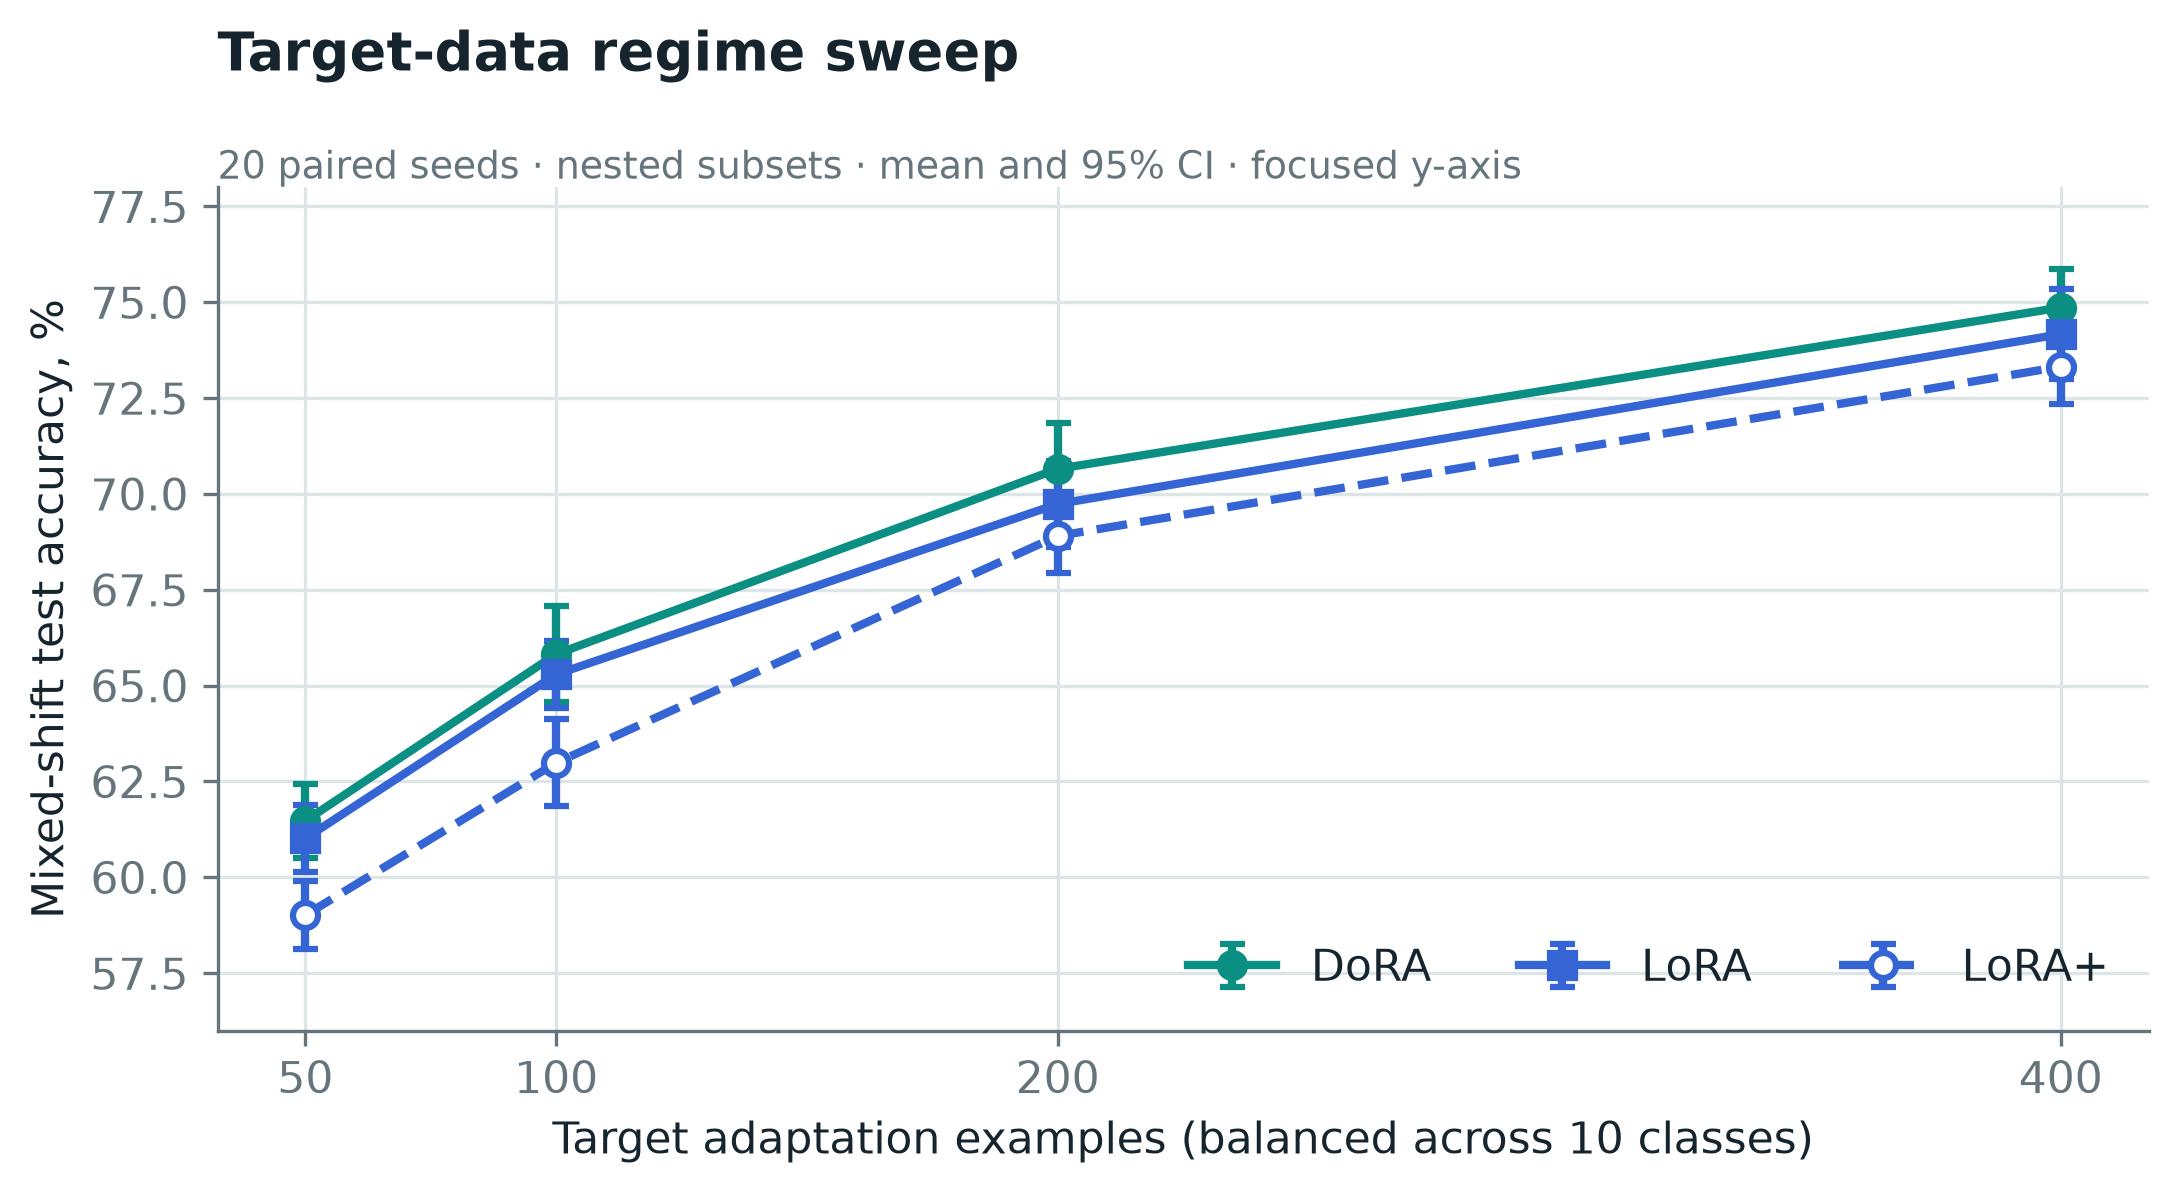

In [8]:
Image(filename=ROOT / "figures" / "extension" / "data_regime_accuracy.png", width=850, embed=True)

## Synthetic capacity versus trainability

LoRA receives its exact rank-4 SVD optimum. Feasible DoRA uses the known generating decomposition. Trained DoRA starts from the standard no-op initialization; the inferential unit is the independent matrix problem, not each optimizer initialization.


In [9]:
synthetic = pd.read_csv(
    ROOT / "results" / "synthetic_optimization" / "synthetic_optimization_verified_summary.csv"
)
synthetic.round(7)

,magnitude_strength,optimized_dora_error_mean,optimized_dora_error_ci95_low,optimized_dora_error_ci95_high,optimized_dora_worst_init_error_mean,feasible_dora_error_mean,lora_oracle_error_mean,lora_oracle_error_ci95_low,lora_oracle_error_ci95_high,convergence_rate_mean,n_independent_problems,initializations_per_problem
0,0.0,0.000003,0.000002,0.000003,0.000006,2.000000e-07,1.000000e-07,1.000000e-07,1.000000e-07,1.00,10,5
1,0.4,0.000002,0.000001,0.000002,0.000002,2.000000e-07,1.740297e-01,1.675886e-01,1.804708e-01,1.00,10,5
2,0.8,0.004440,-0.005265,0.014144,0.004981,2.000000e-07,2.885611e-01,2.800449e-01,2.970773e-01,0.88,10,5


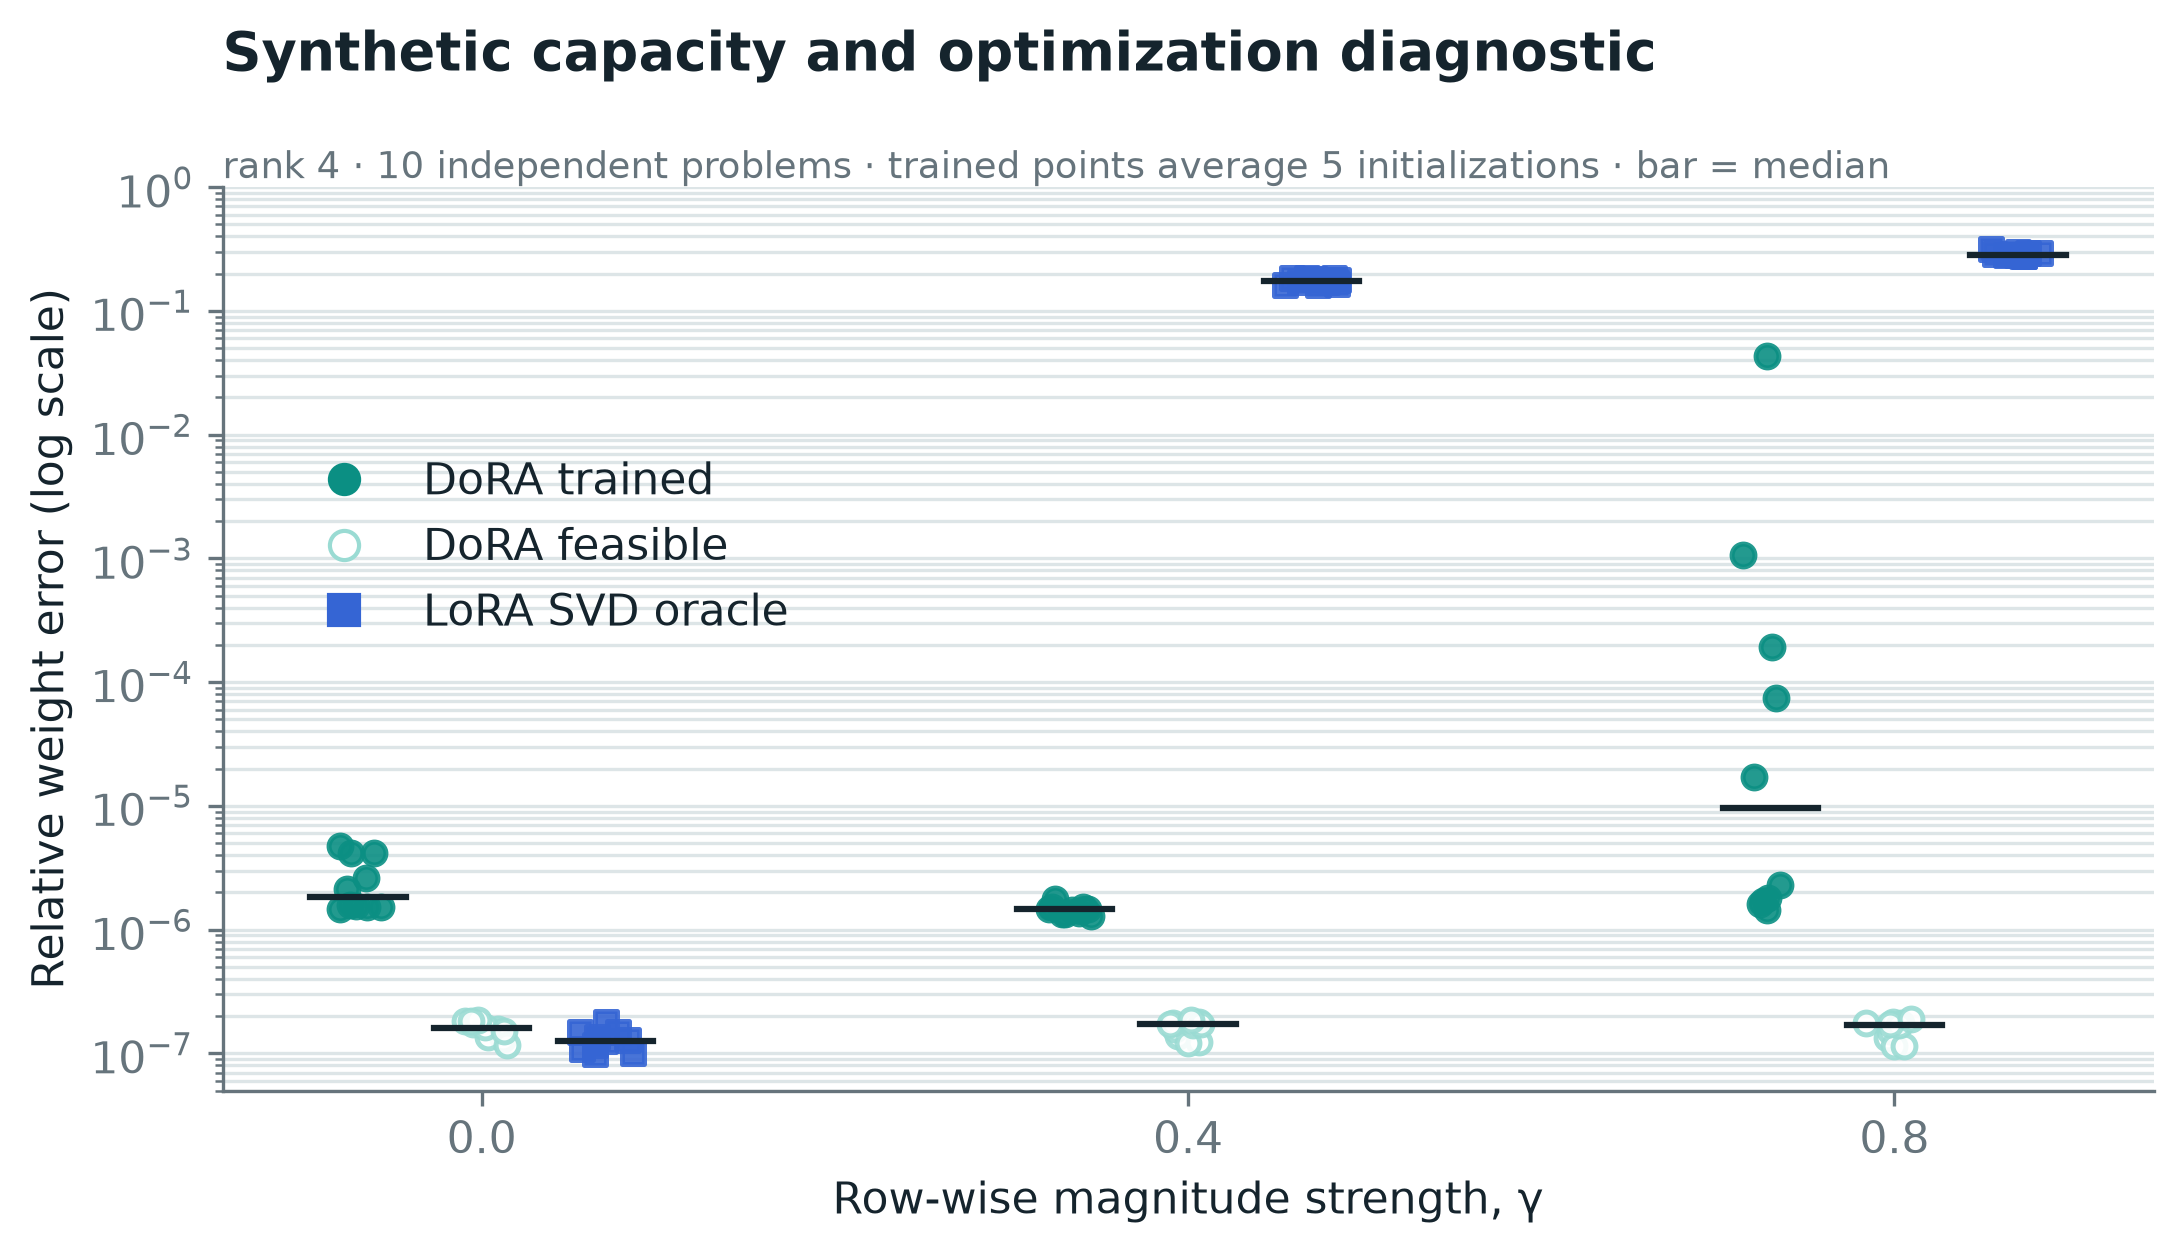

In [10]:
Image(filename=ROOT / "figures" / "extension" / "synthetic_optimization.png", width=850, embed=True)

## Interpretation and limits

1. **Geometry matters.** Mixed direction+magnitude change is the setting in which DoRA is consistently useful.
2. **Parameter count is not the whole explanation.** DoRA remains ahead of a LoRA allocation within ten parameters of its MLP budget, although the interval is wide.
3. **Capacity is not optimization.** The synthetic target is exactly representable, yet strong magnitude shift creates failed DoRA initializations.
4. **Simpler can be better.** Magnitude-only adaptation wins on contrast, and matched LoRA closes rotation.
5. **External validity remains open.** One fixed Digits checkpoint per architecture is not transformer-scale evidence.

The next high-value study is an external, separately frozen PEFT experiment on a small pretrained transformer with matched target modules and multiple base checkpoints.
